Импорты, seed и среда



In [1]:
import random
from typing import Iterable, List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline
)
from transformers.utils.notebook import NotebookProgressCallback


from datasets import load_dataset, Dataset

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


Данные и первичный анализ

In [2]:
dataset = load_dataset("emotion")

print(f"Классы: {dataset['train'].features['label'].names}")
print(f"Размер train: {len(dataset['train'])}, validation: {len(dataset['validation'])}, test: {len(dataset['test'])}")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Размер train: 16000, validation: 2000, test: 2000
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [33]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

df = pd.concat([train_df, val_df, test_df])
label_names = dataset['train'].features['label'].names
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for idx, label in enumerate(label_names)}

df["label_id"] = df["label"].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

display(df.sample(6, random_state=42).reset_index(drop=True))

display("Распределение во всём датасете:", df["label"].value_counts())
display("Train-распределение:", train_df["label"].value_counts())
display("Validation-распределение:" ,val_df["label"].value_counts())
display("Test-распределение:", test_df["label"].value_counts())

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


,text,label,label_id
0,i noticed several months ago that i d start fe...,3,NaN
1,i love lots of different kinds of sports and l...,1,NaN
2,i feel even if he killed himself it was becaus...,0,NaN
3,i feel numb the way a wound does before it rea...,0,NaN
4,i feel very happy to have inspired is my littl...,1,NaN
5,i began to feel unimportant useless insecure a...,0,NaN


'Распределение во всём датасете:'

,count
label,
1,6761
0,5797
3,2709
4,2373
2,1641
5,719


'Train-распределение:'

...

'Validation-распределение:'

,count
label,
1,704
0,550
3,275
4,212
2,178
5,81


'Test-распределение:'

,count
label,
1,695
0,581
3,275
4,224
2,159
5,66


Train: (16000, 2)
Validation: (2000, 2)
Test: (2000, 2)


In [4]:
print("Размер датасета:", len(dataset))
train_data = dataset['train']

print("Размер тренировочного датасета:", len(train_data))

display(pd.Series(train_data["label"]).value_counts())

label_names = train_data.features['label'].names

label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for idx, label in enumerate(label_names)}

print(f"Классы: {label_names}")
print(f"Пример маппинга: {id2label}")

Размер датасета: 3
Размер тренировочного датасета: 16000


,count
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Пример маппинга: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [5]:
label_names = dataset['train'].features['label'].names
for i in range(5):
    item = dataset['train'][i]
    text = item['text']
    label_id = item['label']
    label_name = label_names[label_id]
    print(f"[{label_name.upper():8s}] : \"{text}\"")

[SADNESS ] : "i didnt feel humiliated"
[SADNESS ] : "i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake"
[ANGER   ] : "im grabbing a minute to post i feel greedy wrong"
[LOVE    ] : "i am ever feeling nostalgic about the fireplace i will know that it is still on the property"
[ANGER   ] : "i am feeling grouchy"


In [6]:
# Компактная русскоязычная BERT-подобная модель.
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

texts = [
    dataset["train"][0]["text"],
    dataset["train"][1]["text"],
    dataset["train"][4]["text"],
    dataset["train"][6]["text"]
]


print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: distilbert-base-uncased
Tokenizer class: BertTokenizer
Model max length: 512


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [7]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

input_ids: shape=(3, 23)
token_type_ids: shape=(3, 23)
attention_mask: shape=(3, 23)
labels: shape=(3,)


In [8]:
batch = tokenizer(
    texts,
    padding=True,
    truncation=True,
    add_special_tokens=True,
    return_tensors="pt",
)

num_samples = batch["input_ids"].shape[0]

data = []

for i in range(num_samples):
    original_text = texts[i]

    ids_list = batch["input_ids"][i].tolist()
    mask_list = batch["attention_mask"][i].tolist()

    tokens = tokenizer.convert_ids_to_tokens(ids_list)

    tokens_display = " ".join(tokens)
    ids_display = str(ids_list)
    mask_display = str(mask_list)

    print(f"Пример {i+1}")
    print(f"{original_text:} | {tokens_display:} | input_ids: {ids_display}")
    print(f"{'':25}   {'':45}   attention_mask: {mask_display}\n")

Пример 1
i didnt feel humiliated | [CLS] i didn ##t feel humiliated [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] | input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
                                                                            attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Пример 2
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake | [CLS] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] | input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102, 0, 0, 0, 0, 0, 0, 0]
                       

In [9]:
text_clf = pipeline(
    task="text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    tokenizer=tokenizer,
    device=device,
)

print("Классы датасета:\n", label_names)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Классы датасета:
 ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


Была использовована модель j-hartmann/emotion-english-distilroberta-base. Она уже дообучена (fine-tuned) на задачу классификации эмоций. Это значит, что её последний слой настроен выдавать вероятности именно для классов sadness, joy, love, anger, fear, surprise, поэтому она сразу выдаёт осмысленный результат. Но последний результат спорный, так как тут нужно смотреть на то, как он интерпретирован

In [10]:
emotion_model_name = "j-hartmann/emotion-english-distilroberta-base"
emotion_classifier = pipeline("text-classification", model=emotion_model_name, top_k=None)

test_texts = [
    "I am so happy and excited!",
    "This is terrible and I am angry.",
    "I feel sad and lonely today.",
    "Wow, I didn't expect that at all!",
    "You are always eatting in class!"
]

results = []
for text in test_texts:
    preds = emotion_classifier(text)[0]
    top_pred = max(preds, key=lambda x: x['score'])
    results.append({
        "Text": text,
        "Predicted Emotion": top_pred['label'],
        "Score": f"{top_pred['score']:.2%}"
    })

df_results = pd.DataFrame(results)
display(df_results)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

,Text,Predicted Emotion,Score
0,I am so happy and excited!,joy,98.02%
1,This is terrible and I am angry.,anger,65.73%
2,I feel sad and lonely today.,sadness,98.61%
3,"Wow, I didn't expect that at all!",surprise,97.86%
4,You are always eatting in class!,joy,36.48%


In [11]:
# Вспомогательная функция для ручного инференса одного текста.
def predict_one_text(text: str) -> Dict[str, Any]:
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)

    pred_id = int(torch.argmax(probs, dim=-1).item())
    pred_label = model.config.id2label[pred_id]
    pred_score = float(probs[0, pred_id].item())

    result = {
        "text": text,
        "pred_id": pred_id,
        "pred_label": pred_label,
        "pred_score": pred_score,
        "logits": logits.cpu().numpy().round(4).tolist()[0],
        "probabilities": probs.cpu().numpy().round(4).tolist()[0],
    }
    return result



# Удобная функция для преобразования вероятностей в таблицу.
def probability_table(text: str) -> pd.DataFrame:
    result = predict_one_text(text)
    labels = [model.config.id2label[i] for i in range(model.config.num_labels)]
    df = pd.DataFrame(
        {
            "label": labels,
            "probability": result["probabilities"],
        }
    ).sort_values("probability", ascending=False, ignore_index=True)
    df.insert(0, "text", text)
    return df

In [12]:
label_names = dataset['train'].features['label'].names
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for idx, label in enumerate(label_names)}


# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model class: DistilBertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [13]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [14]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/hw13_aiecity_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [15]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.334856,0.220690,0.932000,0.907340,0.933090
2,0.214846,0.204285,0.940000,0.912864,0.939442
3,0.004589,0.209760,0.937500,0.913126,0.937792
4,0.017691,0.252572,0.938000,0.915277,0.938395
5,0.000263,0.268389,0.941000,0.916681,0.940874


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=10000, training_loss=0.16997454543644563, metrics={'train_runtime': 684.9904, 'train_samples_per_second': 116.79, 'train_steps_per_second': 14.599, 'total_flos': 853624920666528.0, 'train_loss': 0.16997454543644563, 'epoch': 5.0})

Оценка качества и краткий анализ ошибок

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.805908,4.102463,0.00002,0.001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.803059,2.033285,0.00002,0.002,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.764525,3.596474,0.00002,0.003,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.741590,4.209791,0.00002,0.004,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.722155,2.843188,0.00002,0.005,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.773431,2.516367,0.00002,0.006,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.705715,2.859987,0.00002,0.007,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.702918,3.456226,0.00002,0.008,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.576460,3.704297,0.00002,0.009,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.771255,4.951336,0.00002,0.010,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


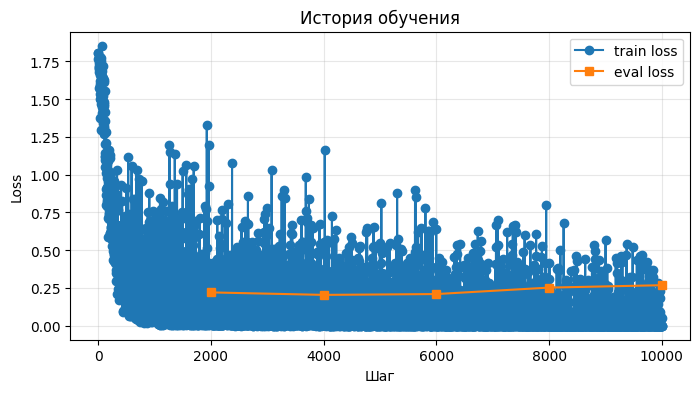

In [17]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("./artifacts/training_curves.png")
plt.show()

In [18]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

Validation metrics:
eval_loss: 0.2684
eval_accuracy: 0.9410
eval_f1_macro: 0.9167
eval_f1_weighted: 0.9409
eval_runtime: 2.9721
eval_samples_per_second: 672.9240
eval_steps_per_second: 84.1150
epoch: 5.0000

Test metrics:
eval_loss: 0.3347
eval_accuracy: 0.9260
eval_f1_macro: 0.8809
eval_f1_weighted: 0.9252
eval_runtime: 2.9506
eval_samples_per_second: 677.8270
eval_steps_per_second: 84.7280
epoch: 5.0000


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.97       581
         joy       0.94      0.94      0.94       695
        love       0.82      0.82      0.82       159
       anger       0.93      0.91      0.92       275
        fear       0.87      0.95      0.91       224
    surprise       0.86      0.64      0.73        66

    accuracy                           0.93      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



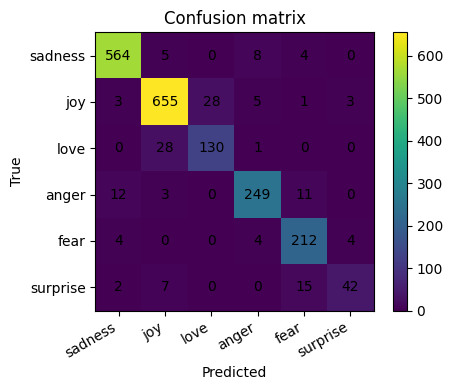

In [19]:
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("./artifacts/confusion_matrix.png")
plt.show()

In [34]:
# Таблица ошибок на тестовой выборке.
test_texts = test_df.reset_index(drop=True)["text"]
error_rows = []

for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, torch.softmax(torch.tensor(test_logits), dim=-1).numpy()):
    if true_id != pred_id:
        error_rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "pred_confidence": float(prob_vector[pred_id]),
        })

errors_df = pd.DataFrame(error_rows)

if len(errors_df) == 0:
    print("На тестовой выборке ошибок не найдено. Это возможно на маленьком учебном датасете.")
else:
    display(errors_df.sort_values(by="pred_confidence", ascending=False).reset_index(drop=True))

errors_df.to_csv("./artifacts/sample_predictions.csv")

,text,true_label,pred_label,pred_confidence
0,whenever i put myself in others shoes and try ...,anger,joy,0.999949
1,i walked to school he felt the bounce in his s...,love,joy,0.999941
2,i do feel terribly remourseful that i didnt st...,love,joy,0.999929
3,i feel affirmed gracious sensuous and will hav...,love,joy,0.999916
4,i feel i can only hope im not alone in these t...,sadness,joy,0.999887
...,...,...,...,...
143,i feel like everything that i hope to become a...,sadness,anger,0.535060
144,i know how it feels to be tortured,anger,fear,0.518331
145,i wept while jackson slept feeling overwhelmed...,fear,surprise,0.502998
146,i seek out pain to feel tortured just to feel ...,fear,anger,0.502825


In [22]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42,
    stratify=train_df["label"],
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts())

print("Распределение классов в validation:")
display(val_df["label"].value_counts())

print("Распределение классов в test:")
display(test_df["label"].value_counts())

Train: (9600, 2)
Validation: (3200, 2)
Test: (3200, 2)

Распределение классов в train:


,count
label,
1,3218
0,2800
3,1295
4,1162
2,782
5,343


Распределение классов в validation:


,count
label,
1,1072
0,933
3,432
4,388
2,261
5,114


Распределение классов в test:


,count
label,
1,1072
0,933
3,432
4,387
2,261
5,115


In [49]:
my_texts = [
    "I am so happy and excited about this!",
    "This is terrible and I am angry.",
    "I feel sad and lonely today.",
    "Etot tekst demonstriruet razbienie na tokeny",
    "Wow, I didn't expect that at all!",
    "The weather is nice today.",
    "Khorosho zhit!",
]

try:
    classifier = emotion_classifier
except NameError:
    classifier = None

with open("tokenization_examples.txt", "w", encoding="utf-8") as f:
    f.write("="*80 + "\n")
    f.write("ПРИМЕРЫ ТОКЕНИЗАЦИИ (Ваши собственные данные)\n")
    f.write("="*80 + "\n\n")

    for i, txt in enumerate(my_texts):
        if classifier:
            preds = classifier(txt)[0]
            top_pred = max(preds, key=lambda x: x['score'])
            label_name = top_pred['label'].upper()
        else:
            label_name = "UNKNOWN"

        # Токенизация
        encoded = tokenizer(txt, padding='max_length', truncation=True, max_length=20, return_tensors='pt')

        ids = encoded['input_ids'][0].tolist()
        mask = encoded['attention_mask'][0].tolist()
        tokens = tokenizer.convert_ids_to_tokens(ids)

        # Запись в файл
        f.write(f"--- Пример {i+1} (Предсказанный класс: {label_name}) ---\n")
        f.write(f"Original Text: \"{txt}\"\n")
        f.write("-"*80 + "\n")
        f.write(f"Tokens      : {' '.join(tokens)}\n")
        f.write(f"Input IDs   : {ids}\n")
        f.write(f"Attention Mask: {mask}\n")
        f.write("\n")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
